# Central meridians: numerical and rendering checks
All ten Python examples are exported directly from the site with `node scripts/export-meridian-cases.mjs`. Check Greenwich (0°), New York (−74°), Tokyo (140°), Mumbai (73°), and longitude wraparound.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

root = Path("/Users/greg/Documents/dev/Map_Projection_Website Development/python-first")
cases = json.loads((root / "notebook-checks/meridian-cases.json").read_text())
meridians = [0, -74, 140, 73, 180, -180, 500]
print(f"{len(cases)} examples; {len(meridians)} meridians")

10 examples; 7 meridians


In [2]:
rng = np.random.default_rng(42)
lon = rng.uniform(-np.pi, np.pi, 2048)
lat = rng.uniform(-1.45, 1.45, 2048)
functions = {}
for case in cases:
    ns = {}
    exec(case["code"], ns)
    assert "central_meridian" in ns, case["name"]
    functions[case["name"]] = ns
    for meridian in meridians:
        ns["central_meridian"] = meridian
        actual = np.column_stack(ns["project"](lon, lat))
        ns["central_meridian"] = 0
        relative_lon = (lon - np.radians(meridian) + np.pi) % (2 * np.pi) - np.pi
        expected = np.column_stack(ns["project"](relative_lon, lat))
        np.testing.assert_allclose(actual, expected, atol=1e-10, equal_nan=True)
        assert np.isfinite(actual).all(axis=1).mean() > 0.99
    print(
        f"PASS {case['name']}: 7 meridians, rotation equivalence and finite coordinates"
    )
print("PASS: 70 projection/meridian combinations")

PASS Mercator: 7 meridians, rotation equivalence and finite coordinates
PASS Gall–Peters: 7 meridians, rotation equivalence and finite coordinates
PASS Equal Earth: 7 meridians, rotation equivalence and finite coordinates
PASS AuthaGraph: 7 meridians, rotation equivalence and finite coordinates
PASS Flip the world upside down: 7 meridians, rotation equivalence and finite coordinates
PASS Slide the latitudes: 7 meridians, rotation equivalence and finite coordinates
PASS Pinch the equator: 7 meridians, rotation equivalence and finite coordinates
PASS Try a logarithm: 7 meridians, rotation equivalence and finite coordinates
PASS Make a wave: 7 meridians, rotation equivalence and finite coordinates
PASS Center on a place: 7 meridians, rotation equivalence and finite coordinates
PASS: 70 projection/meridian combinations


In [3]:
geography = json.loads((root / "public/geo/ne_110m_land.geojson").read_text())
rings = []
for feature in geography["features"]:
    geometry = feature["geometry"]
    polygons = (
        [geometry["coordinates"]]
        if geometry["type"] == "Polygon"
        else geometry["coordinates"]
    )
    for polygon in polygons:
        coords = np.asarray(polygon[0])
        # Densify coastline edges before projecting them.
        parts = [
            np.linspace(a, b, max(2, int(np.max(np.abs(b - a)) / 0.5) + 2))[:-1]
            for a, b in zip(coords[:-1], coords[1:])
        ]
        rings.append(np.radians(np.vstack(parts + [coords[-1:]])))
print(f"Loaded and densified {len(rings)} Natural Earth coastlines")

Loaded and densified 127 Natural Earth coastlines


In [4]:
def render_meridians(names, filename):
    fig, axes = plt.subplots(len(names), 4, figsize=(14, 3 * len(names)))
    fig.patch.set_facecolor("#0b0d0c")
    for row, name in enumerate(names):
        ns = functions[name]
        for col, meridian in enumerate(meridians[:4]):
            ns["central_meridian"] = meridian
            segments = []
            for ring in rings:
                xy = np.column_stack(ns["project"](ring[:, 0], ring[:, 1]))
                edges = np.stack([xy[:-1], xy[1:]], axis=1)
                good = np.isfinite(edges).all(axis=(1, 2))
                good &= np.linalg.norm(edges[:, 1] - edges[:, 0], axis=1) < 0.25
                segments.extend(edges[good])
            assert segments, (name, meridian)
            ax = axes[row, col]
            ax.set_facecolor("#2e2667")
            ax.add_collection(
                LineCollection(segments, colors="#deffaa", linewidths=0.4)
            )
            ax.autoscale()
            ax.set_aspect("equal")
            ax.set_title(f"{name}\n{meridian}°", color="white", fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
    fig.tight_layout()
    fig.savefig(root / "review" / filename, dpi=140, facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved {filename}: {len(names) * 4} coastline renderings")

Saved meridians-lessons.png: 16 coastline renderings


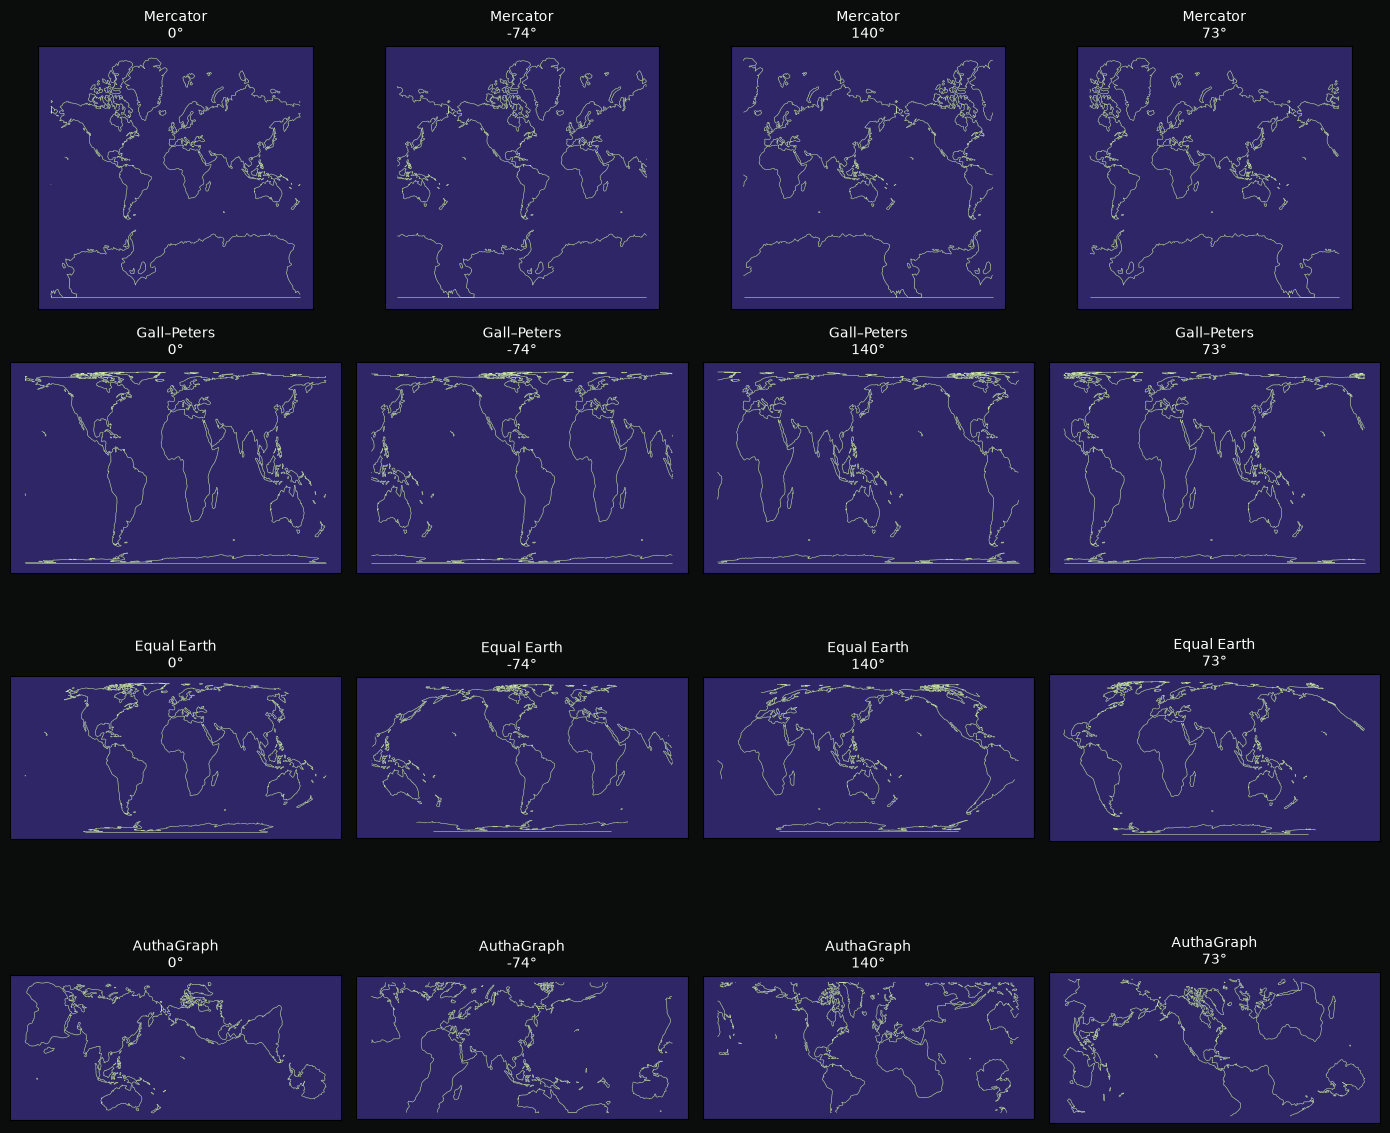

Saved meridians-lessons.png: 16 coastline renderings


In [5]:
render_meridians([c["name"] for c in cases[:4]], "meridians-lessons.png")

Saved meridians-experiments.png: 24 coastline renderings


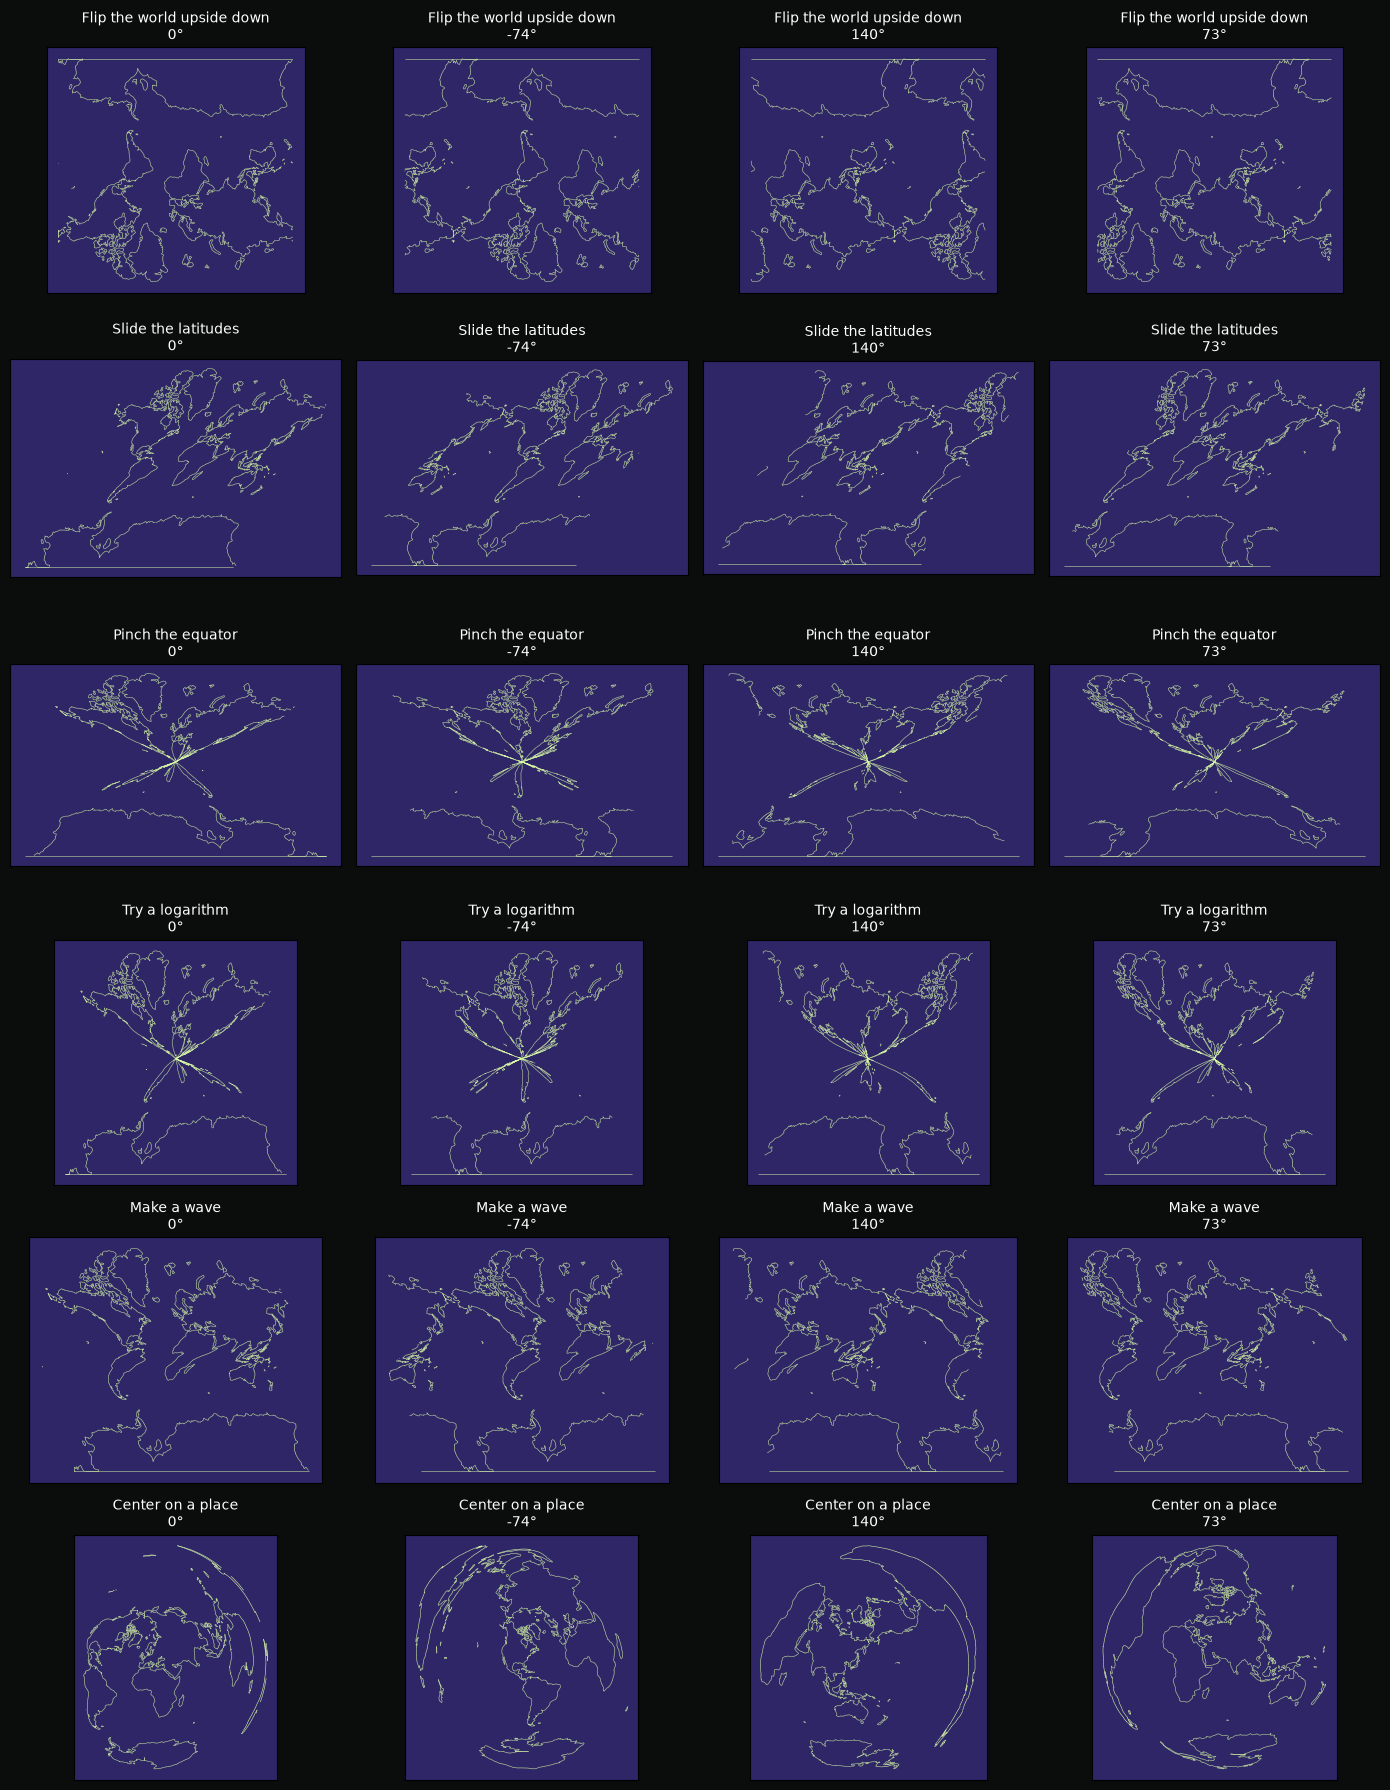

Saved meridians-experiments.png: 24 coastline renderings


In [6]:
render_meridians([c["name"] for c in cases[4:]], "meridians-experiments.png")

In [7]:
print("np" in globals(), "root" in globals())

True True


In [8]:
import json

sign_cases = json.loads((root / "notebook-checks/meridian-cases.json").read_text())
for item in sign_cases[:4]:
    scope = {}
    exec(item["code"], scope)
    scope["central_meridian"] = 0
    reference = np.array(scope["project"](np.array([0.0]), np.array([0.0])))
    for city, longitude in [("New York", -74), ("Tokyo", 140), ("Mumbai", 73)]:
        scope["central_meridian"] = longitude
        point = np.array(scope["project"](np.radians([longitude]), np.array([0.0])))
        np.testing.assert_allclose(point, reference, atol=1e-12)
    print(
        item["name"], "sign checks passed; reference x,y:", reference.ravel().round(4)
    )

Mercator sign checks passed; reference x,y: [ 0. -0.]
Gall–Peters sign checks passed; reference x,y: [0. 0.]
Equal Earth sign checks passed; reference x,y: [0. 0.]
AuthaGraph sign checks passed; reference x,y: [-3.1857  0.9701]
